# Práctica 5 

Alumno: Salvador Calderón Martíenz

Análisis Exploratorio de Datos del dataset `Youtube_toxic.csv`, que contiene comentarios de YouTube etiquetados con distintas categorías de toxicidad (tóxico, abusivo, amenaza, provocador, obsceno, discurso de odio, racista, nacionalista, sexista, homofóbico, odio religioso, radicalismo).

**Contenido:**
1. Carga y estructura de los datos
2. Calidad de datos (nulos, duplicados)
3. Análisis univariado de las categorías de toxicidad
4. Relación entre categorías (co-ocurrencia y correlación)
5. Análisis del texto de los comentarios
6. Regresión Logística


In [1]:
# Importación de librerías

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Modelos
from sklearn.linear_model import LogisticRegression

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)



## 1. Carga y estructura de los datos

In [2]:

# Carga del dataset desde Google Drive
file_id = "1xeACj1OM1fNd7vY1D9z3YbyzTkNXmNtn"

# URL de descarga directa
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Cargar dataset
df = pd.read_csv(url)
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

# Mostrar las primeras filas
df.head()

Dimensiones del dataset: 1000 filas x 15 columnas


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [3]:
# Exploración inicial del dataset
print("\nTamaño del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nValores nulos por columna:")
display(df.isnull().sum())


Tamaño del dataset:
(1000, 15)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CommentId        1000 non-null   str  
 1   VideoId          1000 non-null   str  
 2   Text             1000 non-null   str  
 3   IsToxic          1000 non-null   bool 
 4   IsAbusive        1000 non-null   bool 
 5   IsThreat         1000 non-null   bool 
 6   IsProvocative    1000 non-null   bool 
 7   IsObscene        1000 non-null   bool 
 8   IsHatespeech     1000 non-null   bool 
 9   IsRacist         1000 non-null   bool 
 10  IsNationalist    1000 non-null   bool 
 11  IsSexist         1000 non-null   bool 
 12  IsHomophobic     1000 non-null   bool 
 13  IsReligiousHate  1000 non-null   bool 
 14  IsRadicalism     1000 non-null   bool 
dtypes: bool(12), str(3)
memory usage: 248.3 KB

Estadísticas descriptivas:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000



Valores nulos por columna:


CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64

In [4]:

# Columnas del dataset


print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']


In [5]:
# Columnas booleanas de toxicidad
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Columnas booleanas (categorías de toxicidad):", bool_cols)
print("\nColumnas de texto/ID:", [c for c in df.columns if c not in bool_cols])

Columnas booleanas (categorías de toxicidad): ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

Columnas de texto/ID: ['CommentId', 'VideoId', 'Text']


## 2. Calidad de datos: nulos y duplicados

In [6]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje_%": nulos_pct})
resumen_nulos

,nulos,porcentaje_%
CommentId,0,0.0
VideoId,0,0.0
Text,0,0.0
IsToxic,0,0.0
IsAbusive,0,0.0
IsThreat,0,0.0
IsProvocative,0,0.0
IsObscene,0,0.0
IsHatespeech,0,0.0
IsRacist,0,0.0


In [7]:
dup_filas = df.duplicated().sum()
dup_comentarios = df.duplicated(subset=["Text"]).sum()
dup_ids = df.duplicated(subset=["CommentId"]).sum()
print(f"Filas totalmente duplicadas: {dup_filas}")
print(f"Comentarios (Text) duplicados: {dup_comentarios}")
print(f"CommentId duplicados: {dup_ids}")
print(f"Videos únicos (VideoId): {df['VideoId'].nunique()}")

Filas totalmente duplicadas: 0
Comentarios (Text) duplicados: 3
CommentId duplicados: 0
Videos únicos (VideoId): 13


## 3. Análisis univariado de las categorías de toxicidad

In [8]:
resumen_bool = pd.DataFrame({
    "True (count)": df[bool_cols].sum(),
    "True (%)": (df[bool_cols].sum() / len(df) * 100).round(2)
}).sort_values("True (%)", ascending=False)
resumen_bool

,True (count),True (%)
IsToxic,462,46.2
IsAbusive,353,35.3
IsProvocative,161,16.1
IsHatespeech,138,13.8
IsRacist,125,12.5
IsObscene,100,10.0
IsThreat,21,2.1
IsReligiousHate,12,1.2
IsNationalist,8,0.8
IsSexist,1,0.1


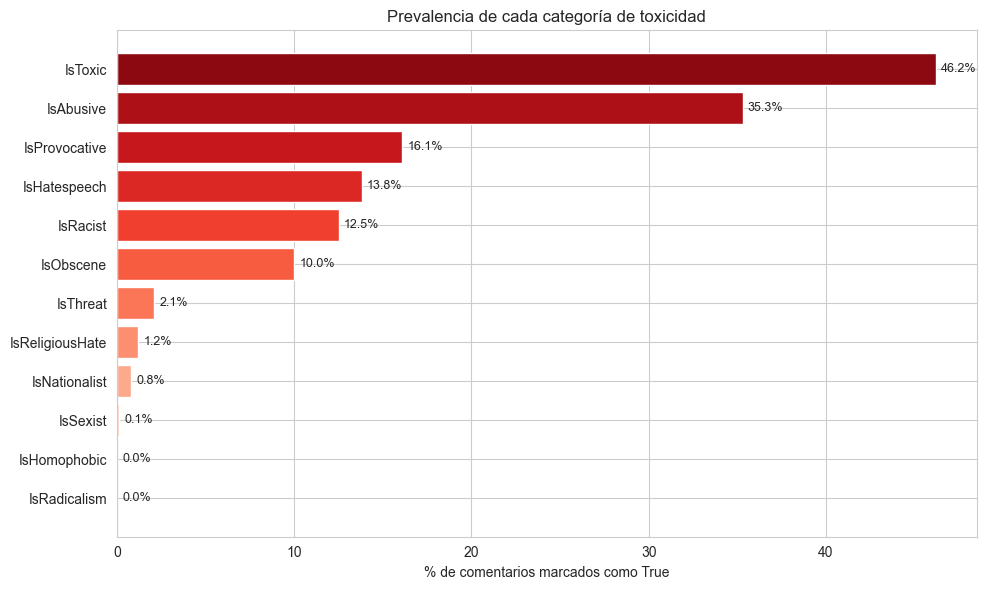

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
orden = resumen_bool.index
valores = resumen_bool["True (%)"]
colors = sns.color_palette("Reds_r", len(orden))
ax.barh(orden, valores, color=colors)
ax.invert_yaxis()
ax.set_xlabel("% de comentarios marcados como True")
ax.set_title("Prevalencia de cada categoría de toxicidad")
for i, v in enumerate(valores):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

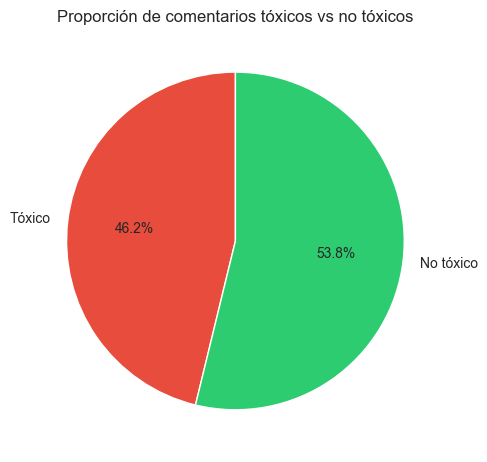

In [10]:
toxic_pct = df["IsToxic"].mean() * 100
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([toxic_pct, 100 - toxic_pct], labels=["Tóxico", "No tóxico"],
       autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90,
       wedgeprops={"edgecolor": "white"})
ax.set_title("Proporción de comentarios tóxicos vs no tóxicos")
plt.tight_layout()
plt.show()


## 4. Relación entre categorías de toxicidad

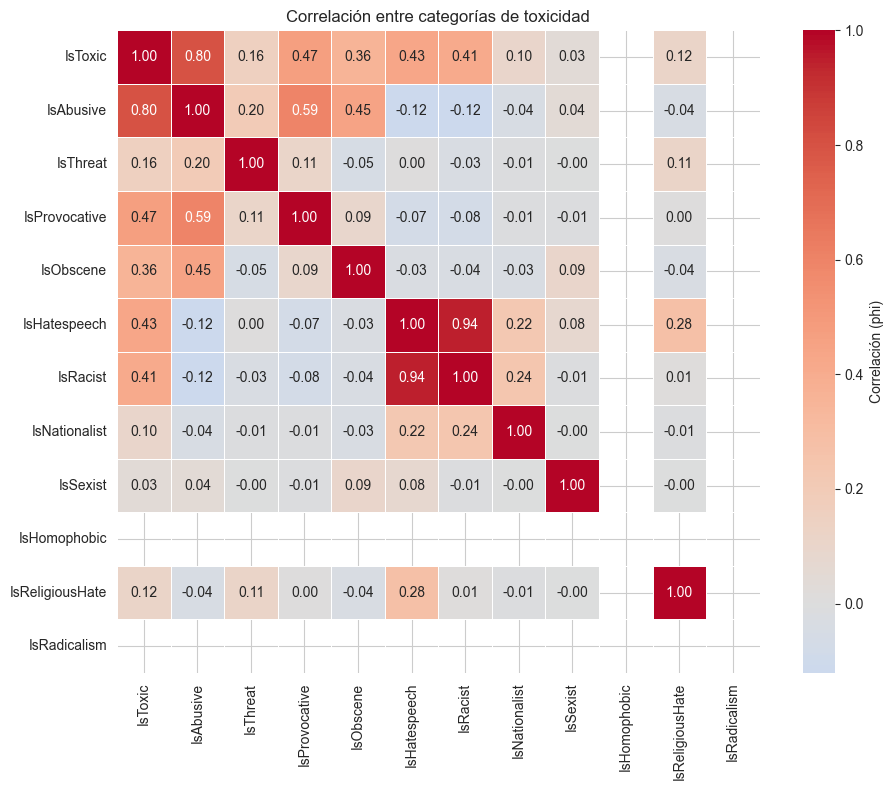

In [11]:
corr = df[bool_cols].astype(int).corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlación (phi)"})
ax.set_title("Correlación entre categorías de toxicidad")
plt.tight_layout()
plt.show()

In [12]:
# Pares de categorías más correlacionadas (excluyendo diagonal y la propia IsToxic)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
corr_pairs.sort_values(ascending=False).head(10)


IsHatespeech  IsRacist           0.944637
IsToxic       IsAbusive          0.797086
IsAbusive     IsProvocative      0.593057
IsToxic       IsProvocative      0.472718
IsAbusive     IsObscene          0.451277
IsToxic       IsHatespeech       0.431774
              IsRacist           0.407869
              IsObscene          0.359707
IsHatespeech  IsReligiousHate    0.275440
IsRacist      IsNationalist      0.237595
dtype: float64

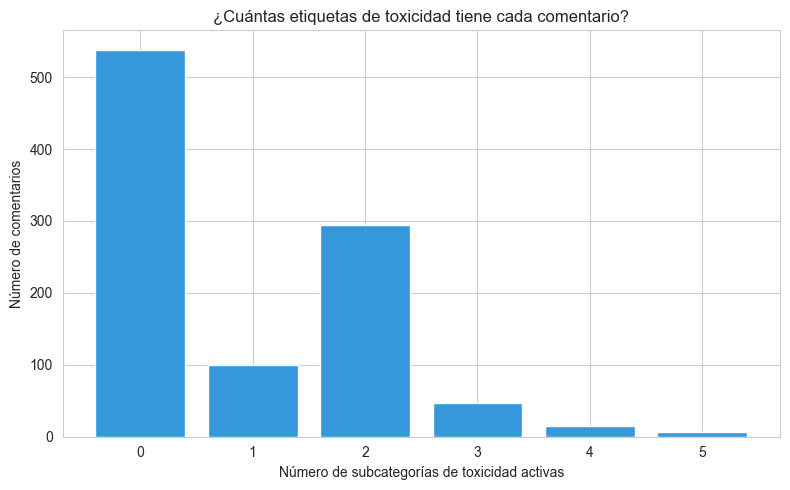

count    1000.000000
mean        0.919000
std         1.116102
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max         5.000000
Name: n_subcategorias, dtype: float64


In [13]:
# Número de categorías de toxicidad activas por comentario (excluyendo IsToxic, que es la etiqueta general)
subcats = [c for c in bool_cols if c != "IsToxic"]
df["n_subcategorias"] = df[subcats].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
counts = df["n_subcategorias"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#3498db")
ax.set_xlabel("Número de subcategorías de toxicidad activas")
ax.set_ylabel("Número de comentarios")
ax.set_title("¿Cuántas etiquetas de toxicidad tiene cada comentario?")
plt.tight_layout()
plt.show()

print(df["n_subcategorias"].describe())

## 5. Análisis del texto de los comentarios

In [14]:
df["longitud_caracteres"] = df["Text"].str.len()
df["longitud_palabras"] = df["Text"].str.split().str.len()

df[["longitud_caracteres", "longitud_palabras"]].describe()

,longitud_caracteres,longitud_palabras
count,1000.000000,1000.000000
mean,185.554000,33.776000
std,270.780777,49.069498
min,3.000000,1.000000
25%,47.000000,9.000000
50%,101.000000,19.000000
75%,217.000000,39.000000
max,4421.000000,815.000000


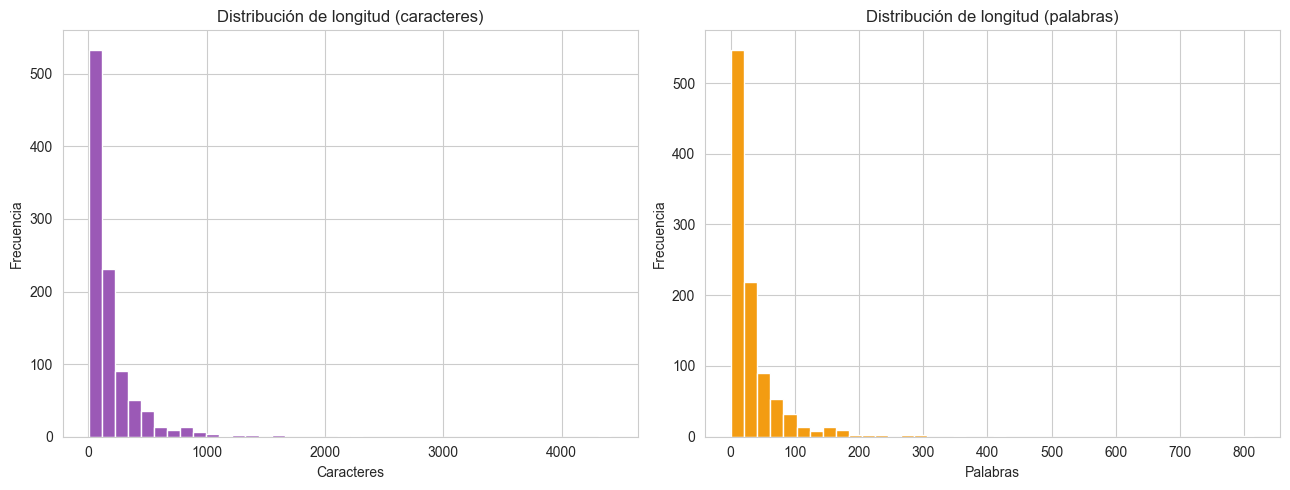

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df["longitud_caracteres"], bins=40, color="#9b59b6", edgecolor="white")
axes[0].set_title("Distribución de longitud (caracteres)")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df["longitud_palabras"], bins=40, color="#f39c12", edgecolor="white")
axes[1].set_title("Distribución de longitud (palabras)")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [16]:
STOPWORDS = set('''a about above after again against all am an and any are aren't as at be because been before
being below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down during
each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same shan't she
she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves then there
there's these they they'd they'll they're they've this those through to too under until up very was wasn't we
we'd we'll we're we've were weren't what what's when when's where where's which while who who's whom why why's
with won't would wouldn't you you'd you'll you're you've your yours yourself yourselves im its youre thats dont
just like get got one would people 2 im really know think say said'''.split())

def tokenize(text):
    words = re.findall(r"[a-z']+", str(text).lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

toxic_words = Counter()
nontoxic_words = Counter()
for text, is_toxic in zip(df["Text"], df["IsToxic"]):
    tokens = tokenize(text)
    if is_toxic:
        toxic_words.update(tokens)
    else:
        nontoxic_words.update(tokens)

print("Top 15 palabras en comentarios TÓXICOS:")
print(toxic_words.most_common(15))
print("\nTop 15 palabras en comentarios NO TÓXICOS:")
print(nontoxic_words.most_common(15))


Top 15 palabras en comentarios TÓXICOS:
[('black', 132), ('white', 78), ('police', 72), ('brown', 51), ('fuck', 51), ('shot', 50), ('will', 48), ('shit', 45), ('can', 41), ('officer', 38), ('cop', 37), ('man', 35), ('cops', 34), ('guy', 33), ('fucking', 33)]

Top 15 palabras en comentarios NO TÓXICOS:
[('black', 121), ('police', 106), ('white', 62), ('video', 61), ('officer', 60), ('brown', 56), ('will', 52), ('cop', 51), ('shot', 45), ('can', 41), ('cops', 35), ('man', 35), ('ferguson', 31), ('right', 30), ('thank', 30)]


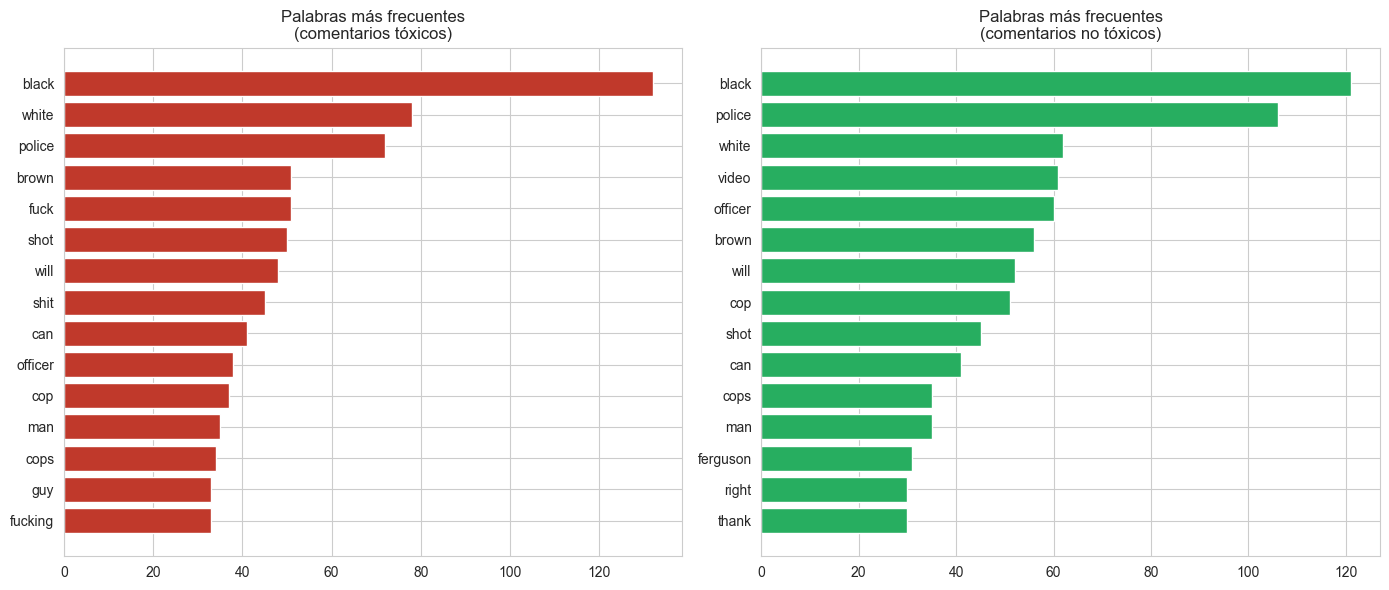

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_toxic = toxic_words.most_common(15)[::-1]
axes[0].barh([w for w, c in top_toxic], [c for w, c in top_toxic], color="#c0392b")
axes[0].set_title("Palabras más frecuentes\n(comentarios tóxicos)")

top_nontoxic = nontoxic_words.most_common(15)[::-1]
axes[1].barh([w for w, c in top_nontoxic], [c for w, c in top_nontoxic], color="#27ae60")
axes[1].set_title("Palabras más frecuentes\n(comentarios no tóxicos)")

plt.tight_layout()
plt.show()

In [18]:
from scipy import stats
toxic_len = df.loc[df["IsToxic"], "longitud_palabras"]
nontoxic_len = df.loc[~df["IsToxic"], "longitud_palabras"]
t_stat, p_value = stats.ttest_ind(toxic_len, nontoxic_len, equal_var=False)
print(f"Longitud media (palabras) - Tóxicos: {toxic_len.mean():.1f} | No tóxicos: {nontoxic_len.mean():.1f}")
print(f"t-test: t={t_stat:.3f}, p-value={p_value:.4f}")

Longitud media (palabras) - Tóxicos: 34.6 | No tóxicos: 33.1
t-test: t=0.488, p-value=0.6256


## 6. Modelo predictivo: Regresión Logística

Se entrena un clasificador de **Regresión Logística** para predecir `IsToxic` a partir del texto del comentario, vectorizado con TF-IDF. Dado el desbalance de clases observado, se usa `class_weight='balanced'` y se evalúa con métricas más informativas que el accuracy (precision, recall, F1 y AUC-ROC).

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, RocCurveDisplay, f1_score)

X = df["Text"]
y = df["IsToxic"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} comentarios | Test: {X_test.shape[0]} comentarios")
print(f"Proporción de tóxicos - Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")


Train: 750 comentarios | Test: 250 comentarios
Proporción de tóxicos - Train: 46.27% | Test: 46.00%


In [20]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"Dimensiones matriz TF-IDF (train): {X_train_tfidf.shape}")


Dimensiones matriz TF-IDF (train): (750, 1831)


In [21]:
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    C=1.0
)
logreg.fit(X_train_tfidf, y_train)

y_pred = logreg.predict(X_test_tfidf)
y_proba = logreg.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No tóxico", "Tóxico"]))

              precision    recall  f1-score   support

   No tóxico       0.73      0.84      0.78       135
      Tóxico       0.77      0.64      0.70       115

    accuracy                           0.75       250
   macro avg       0.75      0.74      0.74       250
weighted avg       0.75      0.75      0.74       250



In [22]:
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
print(f"AUC-ROC: {auc:.3f}")
print(f"F1-score (clase Tóxico): {f1:.3f}")

AUC-ROC: 0.770
F1-score (clase Tóxico): 0.701


c:\Users\scalderonm\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


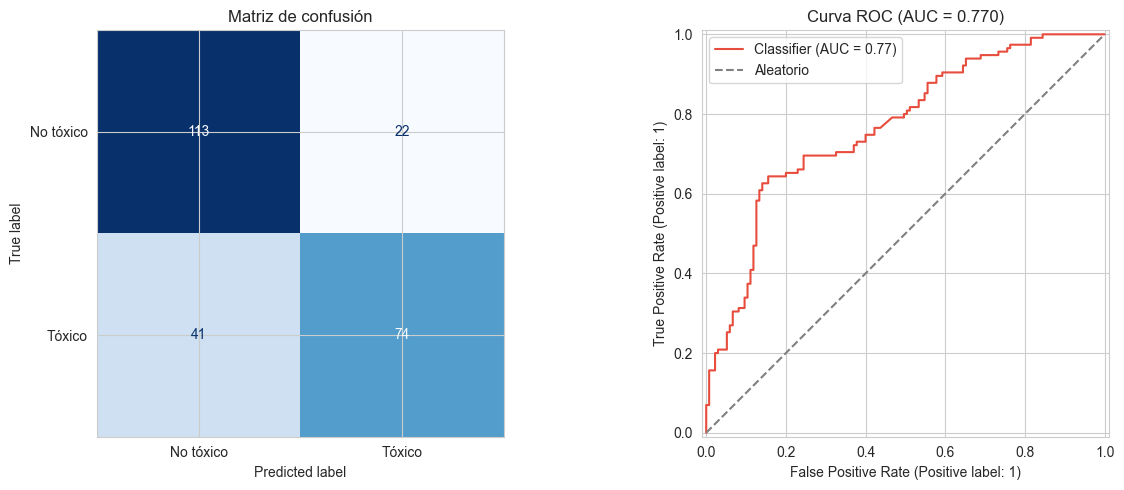

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No tóxico", "Tóxico"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#e74c3c")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[1].set_title(f"Curva ROC (AUC = {auc:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

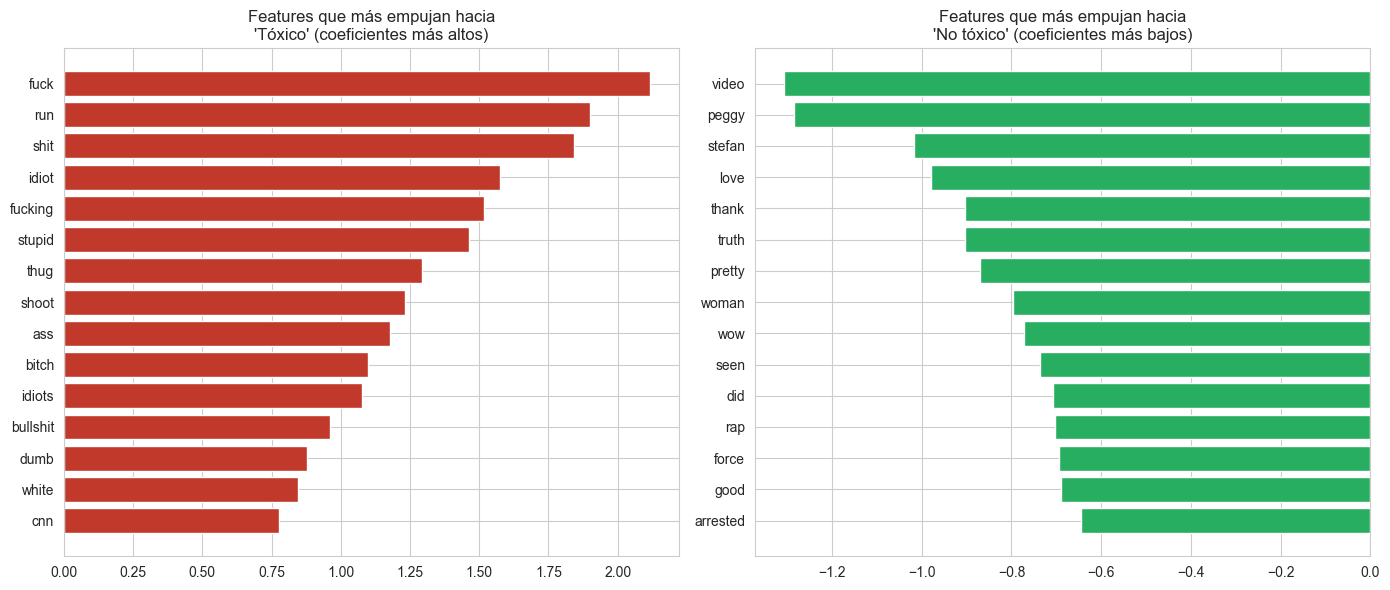

In [24]:
# Palabras (features) más influyentes según los coeficientes del modelo
feature_names = np.array(tfidf.get_feature_names_out())
coefs = logreg.coef_[0]

top_toxic_idx = np.argsort(coefs)[-15:][::-1]
top_nontoxic_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(feature_names[top_toxic_idx][::-1], coefs[top_toxic_idx][::-1], color="#c0392b")
axes[0].set_title("Features que más empujan hacia\n'Tóxico' (coeficientes más altos)")

axes[1].barh(feature_names[top_nontoxic_idx][::-1], coefs[top_nontoxic_idx][::-1], color="#27ae60")
axes[1].set_title("Features que más empujan hacia\n'No tóxico' (coeficientes más bajos)")

plt.tight_layout()
plt.show()
